In [1]:
from load_data import get_2022_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import hdbscan
from sklearn.preprocessing import StandardScaler
import umap

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def do_umap(df_values, random_state: int = 42):
    reduce = umap.UMAP(random_state = random_state)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_values)
    emb = reduce.fit_transform(X_scaled)
    return emb
def gen_clusters(emb, min_cluster_size) -> pd.DataFrame:
    c = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size)
    labels = c.fit_predict(emb)
    df = pd.DataFrame({
        'umap_x' : emb[:, 0],
        'umap_y' : emb[:, 1],
        'labels' : labels
    })
    print(f'HDBSCAN has identified {len(set(labels))} clusters.')
    return df, labels
def gen_clusters2(X, min_cluster_size):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    labels = clusterer.fit_predict(X_scaled)
    print(f'HDBSCAN has identified {len(set(labels))} clusters with min_cluster_size = {min_cluster_size}')


In [5]:
df, meta = get_2022_data()
demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
other_cols = ['Educ6', 'IMD10']
duration_cols = ['MEMS7_ALL']
cols = demographic_cols + other_cols + duration_cols
df = df[cols]
df = df.dropna()
df_encoded = pd.get_dummies(df, columns=['Gend3', 'Disab3','Eth7'])
print(len(df_encoded))
print(df_encoded.head())
mems = df['MEMS7_ALL'].values
exclude = 'MEMS7_ALL'
cluster_cols = [c for c in df_encoded.columns if c != exclude]
cluster_values = df_encoded[cluster_cols].values
gen_clusters2(cluster_values, min_cluster_size = 50)

Data Collected...
Data Shape: (16748, 116)
13254
    Age9  NSSEC5  Educ6  IMD10  MEMS7_ALL  Gend3_1.0  Gend3_2.0  Gend3_3.0  \
10   5.0     1.0    1.0    2.0      652.5      False       True      False   
52   3.0     1.0    1.0    9.0      840.0       True      False      False   
53   3.0     1.0    1.0    5.0        0.0      False       True      False   
54   6.0     3.0    1.0    4.0        0.0       True      False      False   
55   7.0     4.0    5.0    8.0        0.0      False       True      False   

    Disab3_1.0  Disab3_2.0  Disab3_3.0  Eth7_1.0  Eth7_2.0  Eth7_3.0  \
10       False        True       False      True     False     False   
52       False       False        True     False      True     False   
53       False        True       False     False     False     False   
54        True       False       False      True     False     False   
55        True       False       False      True     False     False   

    Eth7_4.0  Eth7_5.0  Eth7_6.0  Eth7_7.0  
10  

Data Collected...
Data Shape: (16748, 116)
13254
    Age9  NSSEC5  Educ6  IMD10  MEMS7_ALL  Gend3_1.0  Gend3_2.0  Gend3_3.0  \
10   5.0     1.0    1.0    2.0      652.5      False       True      False   
52   3.0     1.0    1.0    9.0      840.0       True      False      False   
53   3.0     1.0    1.0    5.0        0.0      False       True      False   
54   6.0     3.0    1.0    4.0        0.0       True      False      False   
55   7.0     4.0    5.0    8.0        0.0      False       True      False   

    Disab3_1.0  Disab3_2.0  Disab3_3.0  Eth7_1.0  Eth7_2.0  Eth7_3.0  \
10       False        True       False      True     False     False   
52       False       False        True     False      True     False   
53       False        True       False     False     False     False   
54        True       False       False      True     False     False   
55        True       False       False      True     False     False   

    Eth7_4.0  Eth7_5.0  Eth7_6.0  Eth7_7.0  
10  

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


HDBSCAN has identified 90 clusters.


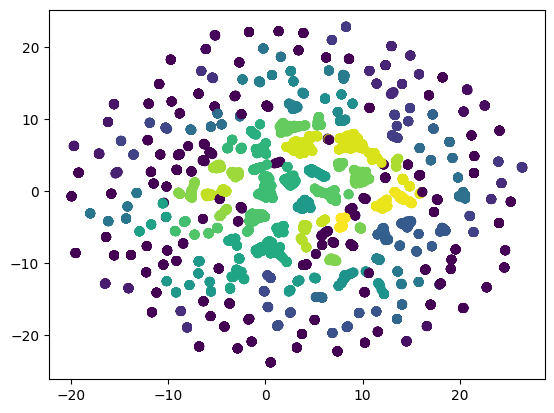

In [7]:
df, meta = get_2022_data()
demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
other_cols = ['Educ6', 'IMD10']
duration_cols = ['MEMS7_ALL']
cols = demographic_cols + other_cols + duration_cols
df = df[cols]
df = df.dropna()
df_encoded = pd.get_dummies(df, columns=['Gend3', 'Disab3','Eth7'])
print(len(df_encoded))
print(df_encoded.head())
mems = df['MEMS7_ALL'].values
exclude = 'MEMS7_ALL'
umap_cols = [c for c in df_encoded.columns if c != exclude]
umap_values = df_encoded[umap_cols].values
emb = do_umap(umap_values, )
df, labels = gen_clusters(emb, min_cluster_size = 50)
plt.scatter(df['umap_x'], df['umap_y'], c=labels)